In [5]:
import pandas as pd

In [6]:
import matplotlib.pyplot as plt

In [9]:
pd.read_csv('menu_items.csv')
pd.read_csv('order_details.csv')

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,01/01/2023,11:38:36 am,109.0
1,2,2,01/01/2023,11:57:40 am,108.0
2,3,2,01/01/2023,11:57:40 am,124.0
3,4,2,01/01/2023,11:57:40 am,117.0
4,5,2,01/01/2023,11:57:40 am,129.0
...,...,...,...,...,...
12229,12230,5369,3/31/23,10:05:04 pm,109.0
12230,12231,5369,3/31/23,10:05:04 pm,129.0
12231,12232,5369,3/31/23,10:05:04 pm,120.0
12232,12233,5369,3/31/23,10:05:04 pm,122.0


In [10]:
menu = pd.read_csv('menu_items.csv')
orders = pd.read_csv('order_details.csv')

In [11]:
menu.head()
orders.head()

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,01/01/2023,11:38:36 am,109.0
1,2,2,01/01/2023,11:57:40 am,108.0
2,3,2,01/01/2023,11:57:40 am,124.0
3,4,2,01/01/2023,11:57:40 am,117.0
4,5,2,01/01/2023,11:57:40 am,129.0


In [12]:
pd.merge(orders, menu, left_on='item_id', right_on='menu_item_id')

,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
0,1,1,01/01/2023,11:38:36 am,109.0,109,Korean Beef Bowl,Asian,17.95
1,2,2,01/01/2023,11:57:40 am,108.0,108,Tofu Pad Thai,Asian,14.50
2,3,2,01/01/2023,11:57:40 am,124.0,124,Spaghetti,Italian,14.50
3,4,2,01/01/2023,11:57:40 am,117.0,117,Chicken Burrito,Mexican,12.95
4,5,2,01/01/2023,11:57:40 am,129.0,129,Mushroom Ravioli,Italian,15.50
...,...,...,...,...,...,...,...,...,...
12092,12230,5369,3/31/23,10:05:04 pm,109.0,109,Korean Beef Bowl,Asian,17.95
12093,12231,5369,3/31/23,10:05:04 pm,129.0,129,Mushroom Ravioli,Italian,15.50
12094,12232,5369,3/31/23,10:05:04 pm,120.0,120,Steak Torta,Mexican,13.95
12095,12233,5369,3/31/23,10:05:04 pm,122.0,122,Chips & Salsa,Mexican,7.00


In [13]:
RS= pd.merge(orders, menu, left_on='item_id', right_on='menu_item_id')

## Most & Least Ordered Items

In [18]:
 RS.groupby(['item_name', 'category']).size().reset_index(name='total_orders')
 item_counts.sort_values(by='total_orders', ascending=False)
 item_counts.sort_values(by='total_orders', ascending=True)


,item_name,category,total_orders
6,Chicken Tacos,Mexican,123
22,Potstickers,Asian,205
1,Cheese Lasagna,Italian,207
28,Steak Tacos,Mexican,214
2,Cheese Quesadillas,Mexican,233
8,Chips & Guacamole,Mexican,237
31,Veggie Burger,American,238
24,Shrimp Scampi,Italian,239
12,Fettuccine Alfredo,Italian,249
15,Hot Dog,American,257


In [17]:
item_counts = RS.groupby(['item_name', 'category']).size().reset_index(name='total_orders')
top_items = item_counts.sort_values(by='total_orders', ascending=False)
least_items = item_counts.sort_values(by='total_orders', ascending=True)

top_items.head(), least_items.head()

(           item_name  category  total_orders
 14         Hamburger  American           622
 10           Edamame     Asian           620
 16  Korean Beef Bowl     Asian           588
 3       Cheeseburger  American           583
 13      French Fries  American           571,
              item_name category  total_orders
 6        Chicken Tacos  Mexican           123
 22         Potstickers    Asian           205
 1       Cheese Lasagna  Italian           207
 28         Steak Tacos  Mexican           214
 2   Cheese Quesadillas  Mexican           233)

## Highest Spending Orders

In [19]:
order_value = RS.groupby('order_id')['price'].sum().reset_index(name='total_spent')
order_value.sort_values(by='total_spent', ascending=False).head()

,order_id,total_spent
435,440,192.15
2064,2075,191.05
1946,1957,190.10
325,330,189.70
2658,2675,185.10


## Peak Order Times

In [21]:
RS['order_time'] = pd.to_datetime(RS['order_time'])
RS['hour'] = RS['order_time'].dt.hour
hourly_orders = RS.groupby('hour').size().reset_index(name='total_orders')
hourly_orders.sort_values(by='total_orders', ascending=False)

C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_11904\710255929.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  RS['order_time'] = pd.to_datetime(RS['order_time'])


,hour,total_orders
2,12,1659
3,13,1558
7,17,1355
8,18,1290
9,19,1074
6,16,1035
4,14,956
10,20,882
5,15,743
1,11,624


## Category Performance

In [22]:
category_sales = RS.groupby('category').size().reset_index(name='total_orders')
category_sales.sort_values(by='total_orders', ascending=False)

,category,total_orders
1,Asian,3470
2,Italian,2948
3,Mexican,2945
0,American,2734


## Visualization: Top Items

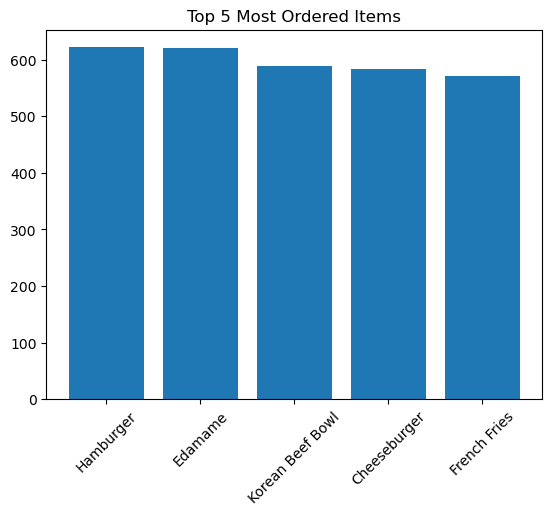

In [65]:
top5 = top_items.head(5)

plt.figure()
plt.bar(top5['item_name'], top5['total_orders'])
plt.xticks(rotation=45)
plt.title('Top 5 Most Ordered Items')
plt.show()

## Visualization: Peak Hours

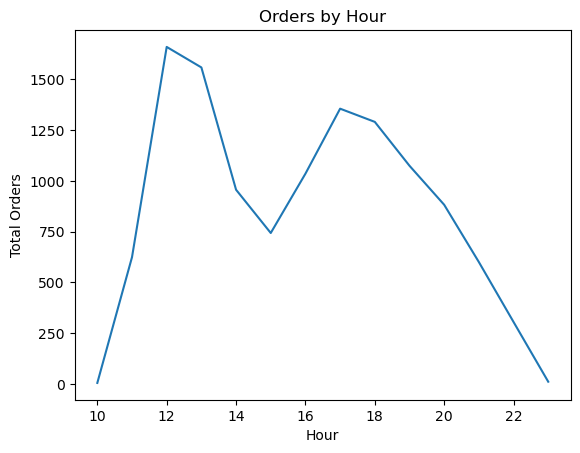

In [66]:
plt.figure()
plt.plot(hourly_orders['hour'], hourly_orders['total_orders'])
plt.title('Orders by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Orders')
plt.show()

## INSIGHTS

In [ ]:
Some items are ordered more than others, so these should always be available and promoted.
Items that are rarely ordered may need improvement or can be removed.

There are certain hours when orders are highest, so more staff should be available during those times.

Some categories bring in more money, so the restaurant can expand those and focus more on them.

Also, customers who spend more show an opportunity to introduce combo deals or special offers.